학습된 데이터 수: 769건
최종 개선된 R2 Score: 0.0111


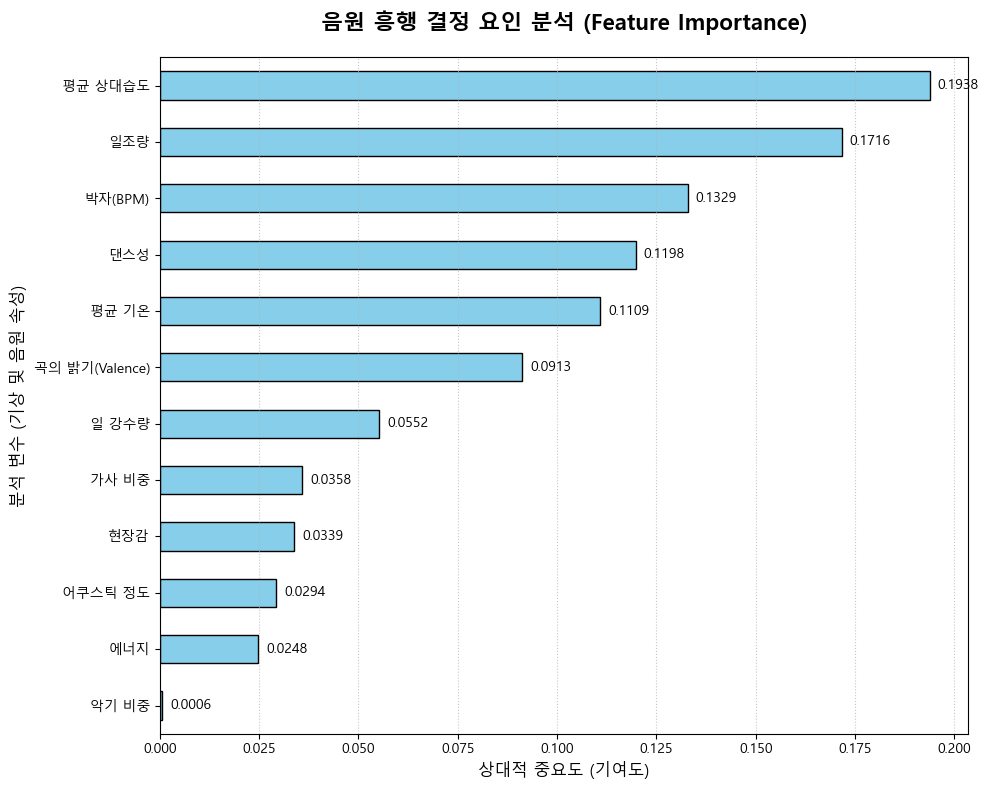

<Figure size 640x480 with 0 Axes>

['spotify_weather_model_v2.pkl']

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import joblib

# 1. 데이터 로드 및 병합
df_spotify = pd.read_csv('spotify-2023.csv', encoding='latin-1')
df_weather = pd.read_csv('weather_2019_2023_total.csv')

# 날짜 형식 통일 및 병합
df_spotify['release_date'] = pd.to_datetime(
    df_spotify['released_year'].astype(str) + '-' + 
    df_spotify['released_month'].astype(str).str.zfill(2) + '-' + 
    df_spotify['released_day'].astype(str).str.zfill(2), 
    errors='coerce'
)
df_weather['일시'] = pd.to_datetime(df_weather['일시'])
df_merged = pd.merge(df_spotify, df_weather, left_on='release_date', right_on='일시', how='inner')

# 2. 데이터 전처리 (결측치 제거 및 로그 변환)
df_merged['streams'] = pd.to_numeric(df_merged['streams'], errors='coerce')
df_merged = df_merged.dropna(subset=['streams'])
df_merged = df_merged[df_merged['streams'] > 0]

# 타겟 변수 로그 변환 (학습 안정성 확보)
df_merged['streams_log'] = np.log1p(df_merged['streams']) 

# 독립 변수(Features) 선택
features = ['bpm', 'danceability_%', 'valence_%', 'energy_%', 'acousticness_%', 
            'instrumentalness_%', 'liveness_%', 'speechiness_%',
            '평균기온(°C)', '일강수량(mm)', '평균 상대습도(%)', '합계 일조시간(hr)']

X = df_merged[features].fillna(0)
y = df_merged['streams_log']

# 3. 모델 학습 (정규화된 랜덤 포레스트 설정)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 과적합 방지를 위해 깊이를 제한한 최종 모델
model = RandomForestRegressor(
    n_estimators=200, 
    max_depth=5, 
    min_samples_leaf=10, 
    random_state=42, 
    n_jobs=-1
)
model.fit(X_train, y_train)

# 4. 학습 결과 확인
y_pred = model.predict(X_test)
print("-" * 30)
print(f"✅ 학습 완료 데이터 수: {len(df_merged)}건")
print(f"✅ 모델 결정계수(R2): {r2_score(y_test, y_pred):.4f}")
print("-" * 30)

# 5. 최종 모델 저장 (서비스 배포용)
joblib.dump(model, 'spotify_weather_model_final.pkl')
print("🚀 모델 파일(spotify_weather_model_final.pkl) 저장 완료!")